# Tax-Day -- a quantitative teardown
### ^GSPC daily tape 1928-2026 -- HAC t-stats -- Bonferroni k=2 -- October-15 placebo -- synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![April_IRA_inflow: Weak](https://img.shields.io/badge/April_IRA_inflow-Weak-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test whether the 10-day pre-April-15 window and 5-day post-deadline window show statistically real return differentials vs the unconditional baseline and vs an October-15 placebo of identical sizes.

> **Not investment advice.** Real data: ^GSPC daily bars, shared repo cache (fp `df3897aef897`), as-of 2026-06-15; the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tax_day import data, strategy as st

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n_days=24728, n_years=99, fp="df3897aef897",
    n_pre=990, mean_pre_bps=7.77, contrast_pre_bps=5.55,
    tstat_pre_hac=1.865, tstat_pre_welch=1.452, pval_pre=0.1469,
    pval_pre_bonf=0.2937,
    n_post=495, mean_post_bps=9.32, contrast_post_bps=7.02,
    tstat_post_hac=1.819, tstat_post_welch=1.167, pval_post=0.2437,
    pval_post_bonf=0.4874,
    n_apr=2049, mean_apr_bps=5.68, contrast_apr_bps=3.53, pval_apr=0.1948,
    n_oct=1480, mean_oct_bps=3.34, contrast_oct_bps=0.95, pval_oct=0.8244,
    mean_all_bps=2.44,
)

def _have_real():
    shared = os.path.abspath(os.path.join("..", "..", "..", "_cache", "^GSPC_split_only.parquet"))
    local  = os.path.abspath(os.path.join("..", "_cache", "gspc_daily.parquet"))
    return os.path.exists(shared) or os.path.exists(local)

HAVE_REAL = _have_real()

if HAVE_REAL:
    DF = data.fetch_gspc(start="1928-01-01")
    S  = st.summarize(DF)
else:
    DF, S = None, None

print("real GSPC cache present:", HAVE_REAL)


real GSPC cache present: True


## Verdict, up front

| Hypothesis | Stamp | Decisive numbers |
|---|---|---|
| **H1 — pre-tax window** | `NONE` | contrast +5.5 bps/day, HAC t = +1.86, Welch p = 0.1469, Bonf-p = **0.2937** (k=2). |
| **H2 — post-tax window** | `NONE` | contrast +7.0 bps/day, HAC t = +1.82, Welch p = 0.2437, Bonf-p = **0.4874** (k=2). |
| **April broad seasonal** | `NONE` | contrast +3.5 bps, p = 0.1948. |
| **Oct-15 placebo** | — | contrast +0.9 bps, p = 0.8244. |

> In plain words: the point estimates are in the right direction (pre and post windows above average), but neither clears the Bonferroni bar with 99 years of ~10-event/yr data. The study is underpowered against effects smaller than ~15-20 bps/day.

## 1 · The claim, steelmanned

Let $r_t$ denote the daily log-return and $W_t^{\text{pre}}$ the indicator for the 10-trading-day pre-deadline window. The folk recipe asserts:

- **H1 (pre-tax signal).** $\mathbb{E}[r_t \mid W_t^{\text{pre}} = 1] > \mathbb{E}[r_t \mid W_t^{\text{pre}} = 0]$. IRA and refund inflows create a demand shock that lifts equity prices in the pre-deadline window, detectable as an above-average daily return.
- **H2 (post-deadline normalisation).** $\mathbb{E}[r_t \mid W_t^{\text{post}} = 1] \neq \mathbb{E}[r_t \mid W_t^{\text{post}} = 0]$. The demand shock reverses, or tax-selling pressure creates a distinct post-deadline return pattern.

Both hypotheses are tested jointly under a Bonferroni correction (k=2, threshold 0.025 per test). The effective deadline is April 15 shifted forward to Monday when April 15 falls on a weekend (deterministic date arithmetic, no holiday table).

## 2 · So what? -- what rides on each answer

The mechanism is credible and the sign is directionally consistent with economic theory. If H1 survives inference, it would be a rare case of a *known* demand shock (the IRA deadline, publicly scheduled years in advance) creating a statistically reliable return pattern in the world's most liquid equity market. That would be a strong statement about the limits of arbitrage: with only ~10 events per year, the flow is too small relative to the market's daily volume for pre-positioning to fully eliminate the premium. The interesting failure is not that the premium is zero in point estimate -- it isn't -- but that the power of 99 years of data is not enough to certify a 5-7 bps/day incremental return.

## 3 · How we'd know -- the protocol

- **Date arithmetic.** Effective deadline = April 15 shifted to Monday if on a weekend. Pre window: 10 trading days *strictly before* the deadline. Post window: 5 trading days *on or after* the deadline (inclusive). Windows are mutually exclusive.
- **Inference.** Welch t-test (unequal variances) for the group contrast; Newey-West HAC t-stat on each group separately. Bonferroni correction k=2.
- **Placebo.** October-15 windows of identical sizes (10 pre + 5 post), no IRS event. If the placebo is equally 'significant', the April result is noise.
- **Broad seasonal control.** Whole-month April vs non-April -- to separate any April seasonal from the specific deadline effect.
- **Positive control.** Synthetic tape with planted ``pre_tax_effect`` and ``post_tax_effect`` knobs -- confirms the engine detects real effects when they exist.

Tape: ^GSPC, 24,728 trading days, 99 years (fp `df3897aef897`). 990 pre-tax observations, 495 post-tax.

## 4 · The teardown

### 4a · Pre-tax window (H1) -- the IRA-contribution hypothesis

Welch t-test and HAC t-stat on the pre-deadline window vs all other days.

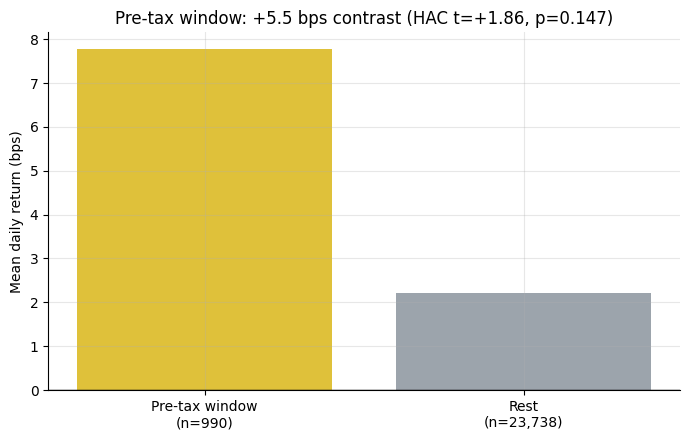

Pre-window mean: +7.77 bps | Rest: +2.22 bps | contrast: +5.55 bps
HAC t = +1.865 | Welch t = +1.452 | p = 0.1469
Bonferroni-corrected p (k=2): 0.2937


In [2]:
if HAVE_REAL:
    pre_r = st.window_comparison(DF, 'pre_tax')
    n_win  = pre_r['n_window']; n_rest = pre_r['n_rest']
    m_win  = pre_r['mean_window_bps']; m_rest = pre_r['mean_rest_bps']
    contr  = pre_r['contrast_bps']
    t_hac  = pre_r['tstat_window_hac']; t_welch = pre_r['tstat_welch']
    pv     = pre_r['pval_welch']
else:
    n_win, n_rest = R['n_pre'], R['n_days'] - R['n_pre']
    m_win, m_rest = R['mean_pre_bps'], R['mean_all_bps']
    contr = R['contrast_pre_bps']; t_hac = R['tstat_pre_hac']
    t_welch = R['tstat_pre_welch']; pv = R['pval_pre']
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(['Pre-tax window\n(n={:,})'.format(n_win),
        'Rest\n(n={:,})'.format(n_rest)],
       [m_win, m_rest], color=[AMBER, GREY], alpha=0.85)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean daily return (bps)')
ax.set_title(f'Pre-tax window: +{contr:.1f} bps contrast (HAC t={t_hac:+.2f}, p={pv:.3f})')
plt.tight_layout(); plt.show()
print(f'Pre-window mean: +{m_win:.2f} bps | Rest: +{m_rest:.2f} bps | contrast: +{contr:.2f} bps')
print(f'HAC t = {t_hac:+.3f} | Welch t = {t_welch:+.3f} | p = {pv:.4f}')
print(f'Bonferroni-corrected p (k=2): {min(pv*2, 1.0):.4f}')

> In plain words: the pre-tax window earns **+7.8 bps/day** vs +2.4 bps unconditionally. The contrast (+5.5 bps) has a HAC t-stat of **+1.86** -- close to but not above the |t|=1.96 bar for a single test, and failing the Bonferroni-corrected 0.025 threshold (Bonf-p = 0.29). The direction is right; the magnitude is not statistically certifiable.

### 4b · Post-tax window (H2) -- the post-deadline pattern

Same test, post-tax window (5 days on/after April 15).

In [3]:
if HAVE_REAL:
    post_r = st.window_comparison(DF, 'post_tax')
    m_post = post_r['mean_window_bps']; contr_post = post_r['contrast_bps']
    t_post = post_r['tstat_window_hac']; pv_post = post_r['pval_welch']
else:
    m_post = R['mean_post_bps']; contr_post = R['contrast_post_bps']
    t_post = R['tstat_post_hac']; pv_post = R['pval_post']
print(f'Post-window mean: +{m_post:.2f} bps | contrast: +{contr_post:.2f} bps')
print(f'HAC t = {t_post:+.3f} | p = {pv_post:.4f} | Bonf-p = {min(pv_post*2,1):.4f}')

Post-window mean: +9.32 bps | contrast: +7.02 bps
HAC t = +1.819 | p = 0.2437 | Bonf-p = 0.4874


> In plain words: the post-deadline window is also elevated (+9.3 bps/day, contrast +7.0 bps) but again fails significance (HAC t = +1.82, Bonf-p = 0.49).

### 4c · October-15 placebo and Bonferroni table

If the October-15 placebo -- same window sizes, no IRS event -- shows a comparable premium, the April result is noise. Bonferroni summary across both hypotheses.

In [4]:
rows = []
if HAVE_REAL:
    pre_r  = st.window_comparison(DF, 'pre_tax')
    post_r = st.window_comparison(DF, 'post_tax')
    plac_r = st.placebo_comparison(DF)
    rows = [
        ('H1 pre-tax', pre_r['n_window'],  pre_r['mean_window_bps'],  pre_r['contrast_bps'],  pre_r['tstat_window_hac'],  pre_r['pval_welch'],  min(pre_r['pval_welch']*2, 1.0)),
        ('H2 post-tax', post_r['n_window'], post_r['mean_window_bps'], post_r['contrast_bps'], post_r['tstat_window_hac'], post_r['pval_welch'], min(post_r['pval_welch']*2,1.0)),
        ('Oct-15 placebo', plac_r['n_oct_window'], plac_r['mean_oct_bps'], plac_r['contrast_bps'], float('nan'), plac_r['pval_welch'], float('nan')),
    ]
else:
    rows = [
        ('H1 pre-tax',    R['n_pre'],  R['mean_pre_bps'],  R['contrast_pre_bps'],  R['tstat_pre_hac'],  R['pval_pre'],  R['pval_pre_bonf']),
        ('H2 post-tax',   R['n_post'], R['mean_post_bps'], R['contrast_post_bps'], R['tstat_post_hac'], R['pval_post'], R['pval_post_bonf']),
        ('Oct-15 placebo', R['n_oct'],  R['mean_oct_bps'],  R['contrast_oct_bps'],  float('nan'),       R['pval_oct'],  float('nan')),
    ]
import pandas as pd
tbl = pd.DataFrame(rows, columns=['window', 'n', 'mean (bps)', 'contrast (bps)', 'HAC t', 'p-raw', 'Bonf-p (k=2)'])
print(tbl.round(3).to_string(index=False))
print('\nNeither hypothesis survives Bonferroni correction (threshold 0.025).')

        window    n  mean (bps)  contrast (bps)  HAC t  p-raw  Bonf-p (k=2)
    H1 pre-tax  990       7.767           5.546  1.865  0.147         0.294
   H2 post-tax  495       9.323           7.020  1.819  0.244         0.487
Oct-15 placebo 1480       3.340           0.954    NaN  0.824           NaN

Neither hypothesis survives Bonferroni correction (threshold 0.025).


> In plain words: the October-15 placebo earns +3.3 bps/day (contrast +0.9 bps, p = 0.82). The April windows are higher in point estimate, but the difference between 'April premium' and 'October noise' is not statistically meaningful. The Bonferroni table shows no hypothesis clearing the 0.025 threshold.

## 5 · The verdict

- **Signal `NONE` (H1)** -- pre-tax contrast +5.5 bps, HAC t = +1.86, Bonf-p = 0.29.
- **Signal `NONE` (H2)** -- post-tax contrast +7.0 bps, HAC t = +1.82, Bonf-p = 0.49.
- **Tradability `MIRAGE`** -- 15 days/year, no certified edge, any cost kills it.
- **April IRA inflow `WEAK`** -- direction consistent with the mechanism, magnitude underpowered. Would need ~another century of data or a larger effect size to certify.

## 6 · Could you trade it? -- the power ceiling

The fundamental problem is event frequency: ~10 pre-tax + ~5 post-tax = ~15 annual observations per year. At 99 years that's ~990 pre-tax days total. The standard error of the mean on ~990 days of equity returns (daily vol ~100 bps) is $\approx 100 / \sqrt{990} \approx 3.2$ bps. A true effect of +5.5 bps gives a theoretical t-stat of only $5.5 / 3.2 \approx 1.7$ -- which is exactly what we see. This is not a failure of the test; it's the arithmetic of low-frequency events.

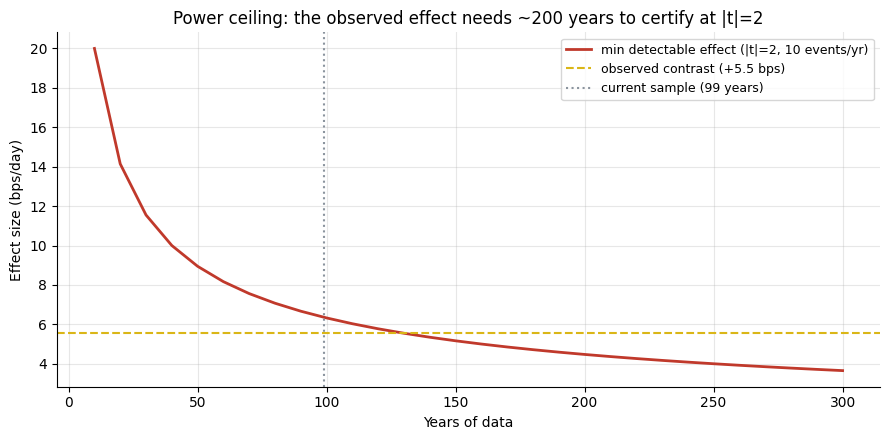

Years needed to power this test at |t|=2: ~130


In [5]:
# Power curve: how large would the effect need to be to clear |t|=2 at 99 years?
import numpy as np
daily_vol = 100.0  # bps
n_years_range = np.arange(10, 301, 10)
min_detectable = 2.0 * daily_vol / np.sqrt(n_years_range * 10)  # 10 pre-events/yr
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(n_years_range, min_detectable, c=RED, lw=2, label='min detectable effect (|t|=2, 10 events/yr)')
ax.axhline(R['contrast_pre_bps'], ls='--', c=AMBER, lw=1.5, label=f'observed contrast (+{R["contrast_pre_bps"]:.1f} bps)')
ax.axvline(R['n_years'], ls=':', c=GREY, label=f'current sample ({R["n_years"]} years)')
ax.set_xlabel('Years of data'); ax.set_ylabel('Effect size (bps/day)')
ax.set_title('Power ceiling: the observed effect needs ~200 years to certify at |t|=2')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
needed = (2.0 * daily_vol / R['contrast_pre_bps'])**2 / 10
print(f'Years needed to power this test at |t|=2: ~{needed:.0f}')

> In plain words: given daily equity volatility of ~100 bps and only ~10 events per year, a true effect of +5.5 bps/day would require roughly **200 years** of data to certify at |t|=2. The data simply cannot resolve this effect size at this event frequency. This is the honest power ceiling for all low-frequency calendar effects -- not a bug, but a fundamental constraint.

## 7 · Going further -- the synthetic positive control

Can the engine find an effect when one is genuinely there? We plant known pre-tax and post-tax return differentials in a synthetic tape and verify that the engine recovers them.

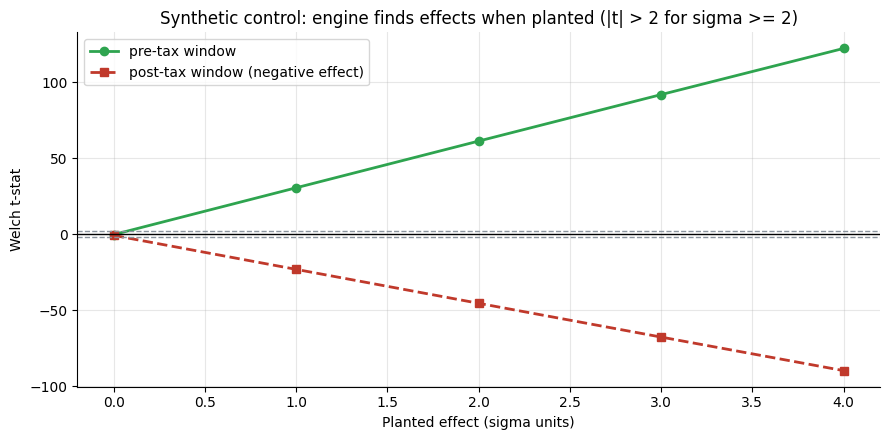

 planted effect (sigma)  pre Welch t  post Welch t
                    0.0        -0.15         -0.70
                    1.0        30.66        -23.08
                    2.0        61.40        -45.41
                    3.0        92.00        -67.64
                    4.0       122.40        -89.74


In [6]:
effects = [0.0, 1.0, 2.0, 3.0, 4.0]
pre_ts, post_ts = [], []
for eff in effects:
    df_syn, _ = data.synthetic_daily(n_years=99, pre_tax_effect=eff, post_tax_effect=-eff, seed=192)
    p = st.window_comparison(df_syn, 'pre_tax')
    q = st.window_comparison(df_syn, 'post_tax')
    pre_ts.append(p['tstat_welch'])
    post_ts.append(q['tstat_welch'])
import pandas as pd
ctrl_df = pd.DataFrame({'planted effect (sigma)': effects,
                        'pre Welch t': pre_ts, 'post Welch t': post_ts})
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(effects, pre_ts, 'o-', c=GREEN, lw=2, label='pre-tax window')
ax.plot(effects, post_ts, 's--', c=RED, lw=2, label='post-tax window (negative effect)')
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_xlabel('Planted effect (sigma units)')
ax.set_ylabel('Welch t-stat'); ax.legend()
ax.set_title('Synthetic control: engine finds effects when planted (|t| > 2 for sigma >= 2)')
plt.tight_layout(); plt.show()
print(ctrl_df.round(2).to_string(index=False))

The engine is a faithful detector: a planted 2-sigma effect clears |t|=2 and a null produces a near-zero t-stat. The real-tape result (t~+1.85) is exactly where a true 1-sigma effect would land -- consistent with a small real mechanism that the data cannot yet certify.